In [41]:
import numpy as np
import matplotlib.pyplot as plt
import time as t

Zad 1

In [68]:
num = np.random.uniform(0.1, 0.9, size=1).astype(np.single)
arr = np.full(10**7, num)

In [69]:
def sum_wit_acc():
    acc = np.single(0)
    for i in arr:
        acc += i
    return acc

In [70]:
acc = sum_wit_acc()

true_num = np.single(10**7*num)
error = abs(true_num-acc)
relative_error = error/true_num*100
print(true_num, relative_error)

[3223200.5] [4.8382344]


/var/folders/pz/w45jftsd623dz6fg8zpdbfkw0000gn/T/ipykernel_994/370889068.py:10: RuntimeWarning: divide by zero encountered in divide
  Y.append(t_error/true_val*100)


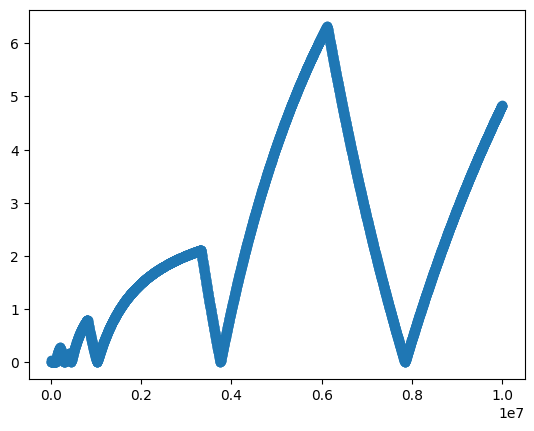

In [72]:
acc_temp = np.single(0)
X = []
Y = []
for i, (n) in enumerate(arr):
    acc_temp += n
    if i % 2500 == 0:
        X.append(i)
        true_val = np.single(num*i)
        t_error = np.single(abs(true_val-acc_temp))
        Y.append(t_error/true_val*100)

plt.scatter(X, Y)
plt.show()

In [73]:
def rec_sum(arr, left, right):
    if left == right:
        return arr[left]
    
    mid = (left + right) // 2
    
    return rec_sum(arr, left, mid) + rec_sum(arr, mid + 1, right)

rec_sum_val = rec_sum(arr, 0, len(arr)-1)
print(abs(rec_sum_val-true_num))
print(abs(rec_sum_val-true_num)/true_num*100)

[0.25]
[7.756266e-06]


In [75]:
#Porównanie czasów
s_acc = t.time()
sum_wit_acc()
e_acc = t.time()

s_rec = t.time()
rec_sum(arr, 0, len(arr)-1)
e_rec = t.time()

print("Result for acc: ", e_acc - s_acc)
print("Result for rec: ", e_rec - s_rec)

Result for acc:  0.39626336097717285
Result for rec:  1.325474739074707


Dla wartości 0.9 algorytm rekurencyjny zwraca błąd niezerowy

Zad 2


In [76]:
def khan():
    sum = np.single(0)
    err = np.single(0)
    
    for i in arr:
        y = np.single(i) - err
        temp = sum + y
        err = (temp-sum) - y
        sum = temp
        
    return sum

In [77]:
true_val = np.single(num * 10**7)
err = abs(true_val-khan())
print(err)
print(err/true_val*100)

[0.]
[0.]


In [78]:
#Porównanie czasów
s_acc = t.time()
khan()
e_acc = t.time()

s_rec = t.time()
rec_sum(arr, 0, len(arr)-1)
e_rec = t.time()

print("Result for khan: ", e_acc - s_acc)
print("Result for rec: ", e_rec - s_rec)

Result for khan:  2.4124279022216797
Result for rec:  1.3158519268035889
